<a href="https://colab.research.google.com/github/bhavya6636/computer-vision/blob/main/Q1124151_COMPUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

DATASET_PATH = "/content/PlantDoc"

print("Dataset path:", DATASET_PATH)
print("\nContents:")

for item in os.listdir(DATASET_PATH):
    print("-", item)

Dataset path: /content/PlantDoc

Contents:
- train
- .git
- PlantDoc_Examples.png
- LICENSE.txt
- test
- README.md


In [ ]:
import os

print(os.listdir("/content"))
print("PlantDoc exists:", os.path.exists("/content/PlantDoc"))

['.config', 'PlantDoc', 'sample_data']
PlantDoc exists: True


In [ ]:
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git /content/PlantDoc

Cloning into '/content/PlantDoc'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 25.35 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


In [ ]:
import os

print("PlantDoc exists:", os.path.exists("/content/PlantDoc"))
print("Train exists:", os.path.exists("/content/PlantDoc/train"))
print("Test exists:", os.path.exists("/content/PlantDoc/test"))

PlantDoc exists: True
Train exists: True
Test exists: True


In [ ]:
train_path = os.path.join(DATASET_PATH, "train")
test_path = os.path.join(DATASET_PATH, "test")

print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))

Train folder exists: True
Test folder exists: True


In [ ]:
# Get class names from training and testing folders

train_classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

test_classes = sorted([
    folder for folder in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, folder))
])

print("Number of training classes:", len(train_classes))
print("Number of testing classes:", len(test_classes))

Number of training classes: 28
Number of testing classes: 27


In [ ]:
# Check whether training and testing contain the same classes

train_only = sorted(set(train_classes) - set(test_classes))
test_only = sorted(set(test_classes) - set(train_classes))

print("Classes only in training:")
print(train_only)

print("\nClasses only in testing:")
print(test_only)

Classes only in training:
['Tomato two spotted spider mites leaf']

Classes only in testing:
[]


In [ ]:
# Count images in a folder

def count_images(folder):
    image_extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            1 for file in files
            if file.endswith(image_extensions)
        )

    return total


train_image_count = count_images(train_path)
test_image_count = count_images(test_path)

print("Training images:", train_image_count)
print("Testing images:", test_image_count)
print("Total images:", train_image_count + test_image_count)

Training images: 2342
Testing images: 236
Total images: 2578


In [ ]:
from collections import Counter

# Count images in each training class
train_class_counts = {}

for class_name in train_classes:
    class_path = os.path.join(train_path, class_name)

    image_count = count_images(class_path)

    train_class_counts[class_name] = image_count


# Display class distribution
print("Training class distribution:\n")

for class_name, count in sorted(train_class_counts.items()):
    print(f"{class_name}: {count}")

Training class distribution:

Apple Scab Leaf: 83
Apple leaf: 82
Apple rust leaf: 79
Bell_pepper leaf: 53
Bell_pepper leaf spot: 62
Blueberry leaf: 106
Cherry leaf: 47
Corn Gray leaf spot: 64
Corn leaf blight: 180
Corn rust leaf: 106
Peach leaf: 103
Potato leaf early blight: 109
Potato leaf late blight: 97
Raspberry leaf: 112
Soyabean leaf: 57
Squash Powdery mildew leaf: 124
Strawberry leaf: 88
Tomato Early blight leaf: 79
Tomato Septoria leaf spot: 140
Tomato leaf: 55
Tomato leaf bacterial spot: 101
Tomato leaf late blight: 101
Tomato leaf mosaic virus: 44
Tomato leaf yellow virus: 70
Tomato mold leaf: 85
Tomato two spotted spider mites leaf: 2
grape leaf: 57
grape leaf black rot: 56


In [ ]:
# Basic statistics of the training class distribution

counts = list(train_class_counts.values())

print("\nClass distribution statistics")
print("--------------------------------")
print("Number of classes:", len(counts))
print("Minimum images in a class:", min(counts))
print("Maximum images in a class:", max(counts))
print("Average images per class:", round(sum(counts) / len(counts), 2))


Class distribution statistics
--------------------------------
Number of classes: 28
Minimum images in a class: 2
Maximum images in a class: 180
Average images per class: 83.64


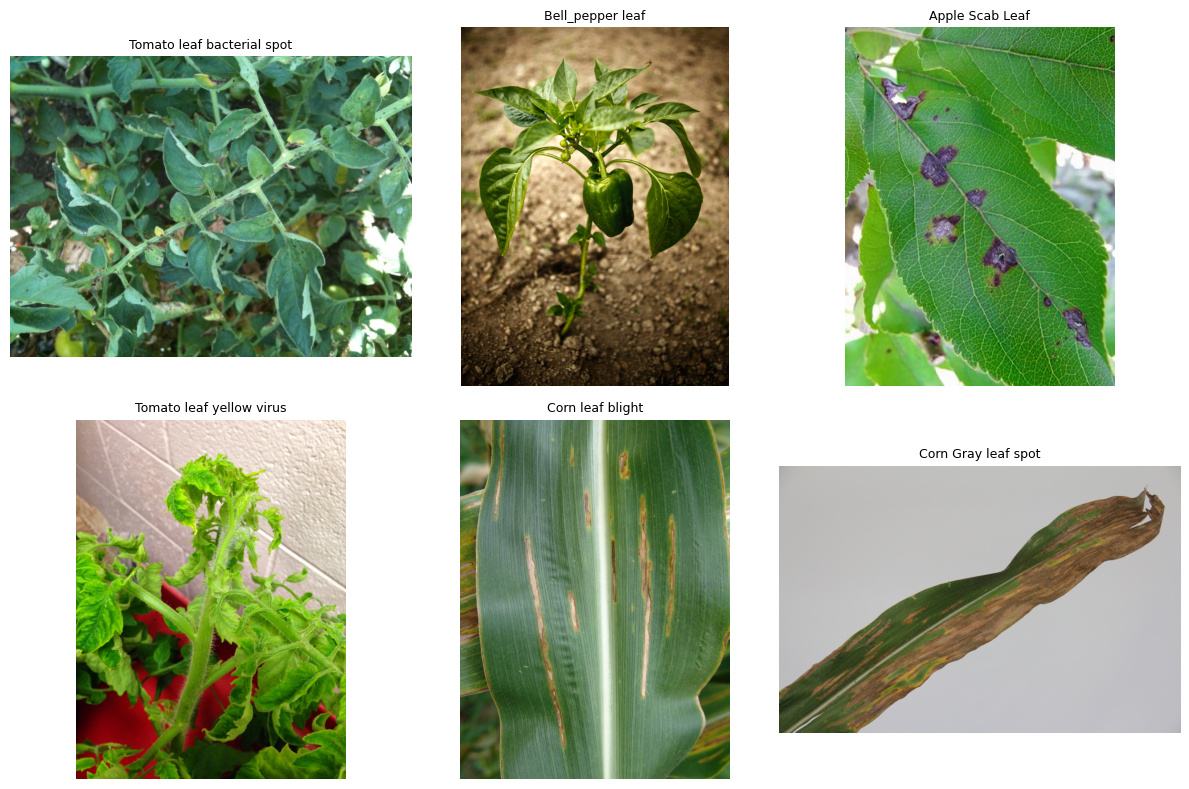

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Select a few classes that have images
available_classes = [
    class_name for class_name in train_classes
    if train_class_counts[class_name] > 0
]

# Randomly select 6 classes
random.seed(42)
selected_classes = random.sample(
    available_classes,
    min(6, len(available_classes))
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, class_name in zip(axes, selected_classes):

    class_path = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(image_files)

    image_path = os.path.join(class_path, image_file)

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

# ImageNet normalization values
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Validation/Test transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Training transformations created successfully.")
print("Validation/Test transformations created successfully.")

Training transformations created successfully.
Validation/Test transformations created successfully.


In [ ]:
print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(test_transform)

Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
# Keep only classes that exist in both training and testing datasets

common_classes = sorted(
    set(train_classes).intersection(set(test_classes))
)

print("Number of common classes:", len(common_classes))

print("\nCommon classes:")
for i, class_name in enumerate(common_classes):
    print(f"{i}: {class_name}")

Number of common classes: 27

Common classes:
0: Apple Scab Leaf
1: Apple leaf
2: Apple rust leaf
3: Bell_pepper leaf
4: Bell_pepper leaf spot
5: Blueberry leaf
6: Cherry leaf
7: Corn Gray leaf spot
8: Corn leaf blight
9: Corn rust leaf
10: Peach leaf
11: Potato leaf early blight
12: Potato leaf late blight
13: Raspberry leaf
14: Soyabean leaf
15: Squash Powdery mildew leaf
16: Strawberry leaf
17: Tomato Early blight leaf
18: Tomato Septoria leaf spot
19: Tomato leaf
20: Tomato leaf bacterial spot
21: Tomato leaf late blight
22: Tomato leaf mosaic virus
23: Tomato leaf yellow virus
24: Tomato mold leaf
25: grape leaf
26: grape leaf black rot


In [ ]:
from sklearn.model_selection import train_test_split

# Store image paths and labels
image_paths = []
image_labels = []

for class_name in common_classes:
    class_path = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(class_path, file_name))
            image_labels.append(class_name)

print("Total usable training images:", len(image_paths))
print("Total labels:", len(image_labels))

Total usable training images: 2340
Total labels: 2340


In [ ]:
# First split:
# 85% training pool
# 15% validation

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.15,
    random_state=42,
    stratify=image_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

Training images: 1989
Validation images: 351


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class PlantDiseaseDataset(Dataset):

    def __init__(self, image_paths, labels, class_names, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_names = class_names
        self.transform = transform

        # Convert class names to numerical labels
        self.class_to_index = {
            class_name: index
            for index, class_name in enumerate(class_names)
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        class_name = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        label = self.class_to_index[class_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = PlantDiseaseDataset(
    train_paths,
    train_labels,
    common_classes,
    transform=train_transform
)

val_dataset = PlantDiseaseDataset(
    val_paths,
    val_labels,
    common_classes,
    transform=test_transform
)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 1989
Validation dataset size: 351


In [ ]:
# Create test image paths and labels

test_paths = []
test_labels = []

for class_name in common_classes:

    class_path = os.path.join(test_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            test_paths.append(
                os.path.join(class_path, file_name)
            )

            test_labels.append(class_name)

print("Test images:", len(test_paths))
print("Test labels:", len(test_labels))

Test images: 236
Test labels: 236


In [ ]:
test_dataset = PlantDiseaseDataset(
    test_paths,
    test_labels,
    common_classes,
    transform=test_transform
)

print("Test dataset size:", len(test_dataset))

Test dataset size: 236


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully.
Training batches: 63
Validation batches: 11
Testing batches: 8


In [ ]:
# Verify one training batch

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Number of classes:", len(common_classes))

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Number of classes: 27


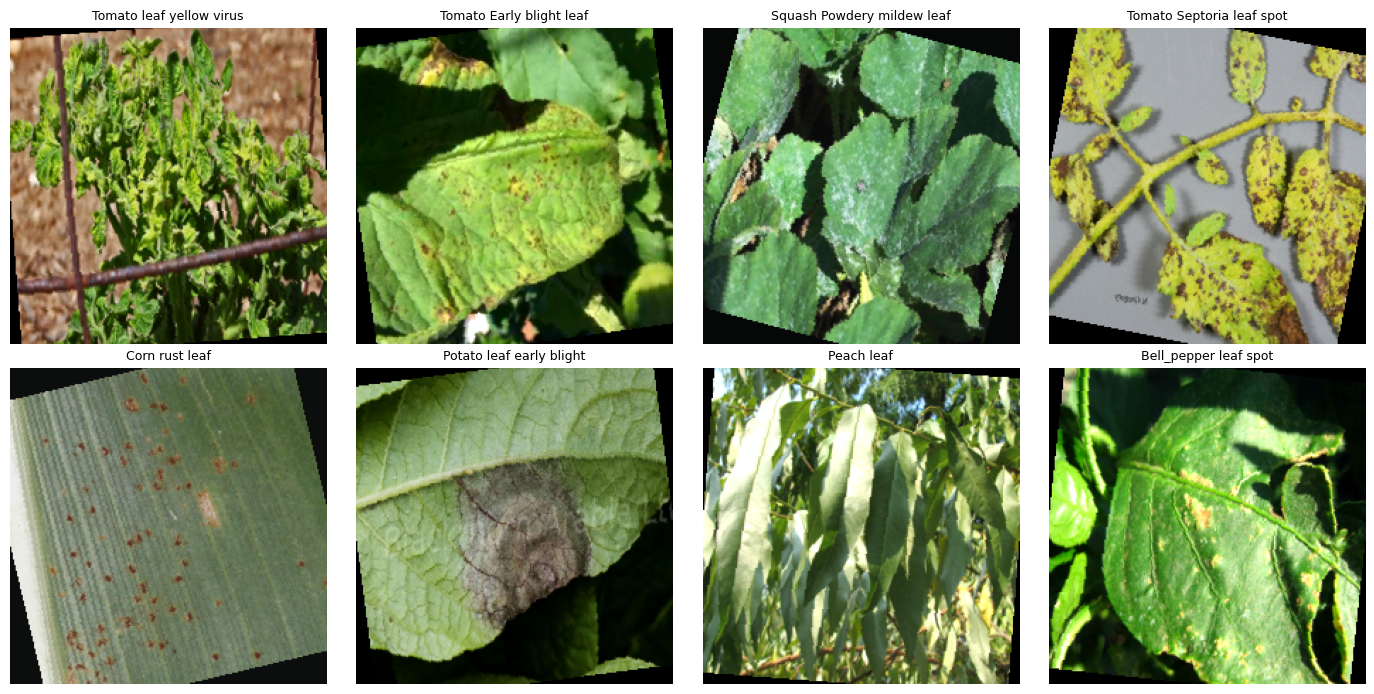

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class index to class name
index_to_class = {
    index: class_name
    for index, class_name in enumerate(common_classes)
}

# Get one batch
images, labels = next(iter(train_loader))

# Display 8 images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):

    # Convert tensor from CHW to HWC
    image = images[i].permute(1, 2, 0).numpy()

    # Undo ImageNet normalization for display
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)

    image = image * std + mean
    image = np.clip(image, 0, 1)

    axes[i].imshow(image)

    class_name = index_to_class[labels[i].item()]
    axes[i].set_title(class_name, fontsize=9)

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Number of classes
num_classes = 27

# Load ImageNet-pretrained ResNet18
baseline_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the original classification layer
baseline_model.fc = nn.Linear(
    baseline_model.fc.in_features,
    num_classes
)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
baseline_model = baseline_model.to(device)

print("Baseline ResNet18 created successfully.")
print("Number of output classes:", num_classes)
print("Device:", device)
print("Final classification layer:", baseline_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]

Baseline ResNet18 created successfully.
Number of output classes: 27
Device: cpu
Final classification layer: Linear(in_features=512, out_features=27, bias=True)


In [ ]:
# Count model parameters

total_params = sum(
    p.numel()
    for p in baseline_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in baseline_model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11190363
Trainable parameters: 11190363


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Channel Attention Module
class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))

        attention = self.sigmoid(avg_out + max_out)

        return x * attention


# Spatial Attention Module
class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        combined = torch.cat([avg_out, max_out], dim=1)

        attention = self.sigmoid(self.conv(combined))

        return x * attention


# Complete CBAM module
class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.channel_attention = ChannelAttention(
            channels,
            reduction
        )

        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        x = self.channel_attention(x)
        x = self.spatial_attention(x)

        return x

In [ ]:
from torchvision import models
import torch.nn as nn


class ResNet18_CBAM(nn.Module):

    def __init__(self, num_classes=27):

        super().__init__()

        # Load ImageNet-pretrained ResNet18
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        # Add CBAM after each major ResNet stage
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)

        # Replace final classification layer
        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features,
            num_classes
        )

    def forward(self, x):

        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.cbam1(x)

        x = self.backbone.layer2(x)
        x = self.cbam2(x)

        x = self.backbone.layer3(x)
        x = self.cbam3(x)

        x = self.backbone.layer4(x)
        x = self.cbam4(x)

        x = self.backbone.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.backbone.fc(x)

        return x

In [ ]:
# Create proposed ResNet18 + CBAM model

proposed_model = ResNet18_CBAM(num_classes=27)

# Move model to available device
proposed_model = proposed_model.to(device)

print("Proposed ResNet18 + CBAM created successfully.")
print("Number of output classes:", 27)
print("Device:", device)
print("Final classification layer:", proposed_model.backbone.fc)

Proposed ResNet18 + CBAM created successfully.
Number of output classes: 27
Device: cpu
Final classification layer: Linear(in_features=512, out_features=27, bias=True)


In [ ]:
# Restore device configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device restored successfully:", device)

Device restored successfully: cpu


In [ ]:
# Count parameters of the proposed model

proposed_total_params = sum(
    p.numel()
    for p in proposed_model.parameters()
)

proposed_trainable_params = sum(
    p.numel()
    for p in proposed_model.parameters()
    if p.requires_grad
)

print("Proposed ResNet18 + CBAM parameters:")
print("Total parameters:", proposed_total_params)
print("Trainable parameters:", proposed_trainable_params)

print("\nBaseline ResNet18 parameters:")
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

# Calculate parameter increase
parameter_increase = (
    (proposed_trainable_params - trainable_params)
    / trainable_params
) * 100

print("\nParameter increase:", round(parameter_increase, 2), "%")

Proposed ResNet18 + CBAM parameters:
Total parameters: 11234275
Trainable parameters: 11234275

Baseline ResNet18 parameters:
Total parameters: 11190363
Trainable parameters: 11190363

Parameter increase: 0.39 %


In [ ]:
# Step 5.1 - Training configuration

import torch.nn as nn
import torch.optim as optim

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizers
baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

proposed_optimizer = optim.Adam(
    proposed_model.parameters(),
    lr=0.001
)

# Training settings
EPOCHS = 10
BATCH_SIZE = 32

print("Training configuration:")
print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Training configuration:
Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001
Batch size: 32
Epochs: 10


In [ ]:
# Step 5.2 - Reusable training and validation loop

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / val_total
        val_accuracy = 100 * val_correct / val_total

        # Store results
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "train_accuracy": train_accuracies,
        "val_accuracy": val_accuracies
    }

    return model, history

In [ ]:
print("Training function created successfully.")
print("Training epochs:", EPOCHS)
print("Training batch size:", BATCH_SIZE)
print("Validation monitoring: Enabled")

Training function created successfully.
Training epochs: 10
Training batch size: 32
Validation monitoring: Enabled


In [ ]:
# Step 5.3 - Train baseline ResNet18

print("Starting baseline ResNet18 training...")

baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=baseline_optimizer,
    epochs=EPOCHS,
    device=device
)

print("\nBaseline ResNet18 training completed.")

Starting baseline ResNet18 training...
Epoch [1/10] | Train Loss: 2.5743 | Train Acc: 25.44% | Val Loss: 2.6384 | Val Acc: 28.21%
Epoch [2/10] | Train Loss: 2.0311 | Train Acc: 38.01% | Val Loss: 2.2607 | Val Acc: 31.34%
Epoch [3/10] | Train Loss: 1.7851 | Train Acc: 43.79% | Val Loss: 2.1514 | Val Acc: 42.74%
Epoch [4/10] | Train Loss: 1.6357 | Train Acc: 48.37% | Val Loss: 1.9181 | Val Acc: 45.87%
Epoch [5/10] | Train Loss: 1.4690 | Train Acc: 53.14% | Val Loss: 1.8697 | Val Acc: 44.16%
Epoch [6/10] | Train Loss: 1.2506 | Train Acc: 59.28% | Val Loss: 2.2443 | Val Acc: 44.16%
Epoch [7/10] | Train Loss: 1.3417 | Train Acc: 57.72% | Val Loss: 1.8140 | Val Acc: 46.44%
Epoch [8/10] | Train Loss: 1.0893 | Train Acc: 64.25% | Val Loss: 2.1436 | Val Acc: 46.44%
Epoch [9/10] | Train Loss: 0.9776 | Train Acc: 66.82% | Val Loss: 1.7911 | Val Acc: 48.43%
Epoch [10/10] | Train Loss: 0.9088 | Train Acc: 69.78% | Val Loss: 1.8254 | Val Acc: 51.00%

Baseline ResNet18 training completed.


In [ ]:
# Recreate the dataset objects for Step 5.3

import os
import torch
from torch.utils.data import Dataset
from PIL import Image
from sklearn.model_selection import train_test_split

# Make sure paths exist
DATASET_PATH = "/content/PlantDoc"
train_path = os.path.join(DATASET_PATH, "train")
test_path = os.path.join(DATASET_PATH, "test")

# Get common classes
train_classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

test_classes = sorted([
    folder for folder in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, folder))
])

common_classes = sorted(
    set(train_classes).intersection(set(test_classes))
)

print("Number of common classes:", len(common_classes))

# Collect training image paths and labels
image_paths = []
image_labels = []

for class_name in common_classes:

    class_path = os.path.join(train_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(
                os.path.join(class_path, file_name)
            )

            image_labels.append(class_name)

# Stratified 85/15 split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.15,
    random_state=42,
    stratify=image_labels
)

# Dataset class
class PlantDiseaseDataset(Dataset):

    def __init__(self, image_paths, labels, class_names, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.class_names = class_names
        self.transform = transform

        self.class_to_index = {
            class_name: index
            for index, class_name in enumerate(class_names)
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        class_name = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        label = self.class_to_index[class_name]

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = PlantDiseaseDataset(
    train_paths,
    train_labels,
    common_classes,
    transform=train_transform
)

val_dataset = PlantDiseaseDataset(
    val_paths,
    val_labels,
    common_classes,
    transform=test_transform
)

# Create test paths and labels
test_paths = []
test_labels = []

for class_name in common_classes:

    class_path = os.path.join(test_path, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            test_paths.append(
                os.path.join(class_path, file_name)
            )

            test_labels.append(class_name)


test_dataset = PlantDiseaseDataset(
    test_paths,
    test_labels,
    common_classes,
    transform=test_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))
print("Classes:", len(common_classes))

Number of common classes: 27
Training dataset: 1989
Validation dataset: 351
Test dataset: 236
Classes: 27


In [ ]:
# Step 5.4 - Train proposed ResNet18 + CBAM

print("Starting proposed ResNet18 + CBAM training...")

proposed_model, proposed_history = train_model(
    model=proposed_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=proposed_optimizer,
    epochs=EPOCHS,
    device=device
)

print("\nProposed ResNet18 + CBAM training completed.")

Starting proposed ResNet18 + CBAM training...
Epoch [1/10] | Train Loss: 2.5264 | Train Acc: 26.19% | Val Loss: 2.4003 | Val Acc: 28.21%
Epoch [2/10] | Train Loss: 2.1487 | Train Acc: 34.59% | Val Loss: 2.5038 | Val Acc: 29.91%
Epoch [3/10] | Train Loss: 1.8573 | Train Acc: 41.38% | Val Loss: 2.0306 | Val Acc: 36.75%
Epoch [4/10] | Train Loss: 1.7374 | Train Acc: 43.99% | Val Loss: 2.2723 | Val Acc: 33.05%
Epoch [5/10] | Train Loss: 1.4993 | Train Acc: 50.53% | Val Loss: 2.8183 | Val Acc: 31.62%
Epoch [6/10] | Train Loss: 1.4201 | Train Acc: 53.49% | Val Loss: 2.1618 | Val Acc: 37.89%
Epoch [7/10] | Train Loss: 1.2881 | Train Acc: 57.42% | Val Loss: 1.9422 | Val Acc: 48.15%
Epoch [8/10] | Train Loss: 1.2483 | Train Acc: 59.13% | Val Loss: 1.8339 | Val Acc: 49.86%
Epoch [9/10] | Train Loss: 1.1331 | Train Acc: 62.09% | Val Loss: 1.8320 | Val Acc: 46.72%
Epoch [10/10] | Train Loss: 1.0316 | Train Acc: 64.76% | Val Loss: 1.9604 | Val Acc: 45.30%

Proposed ResNet18 + CBAM training complete

In [ ]:
# Step 5.5 - Save training results and trained models

import torch

# Save trained model weights
torch.save(
    baseline_model.state_dict(),
    "/content/baseline_resnet18_trained.pth"
)

torch.save(
    proposed_model.state_dict(),
    "/content/proposed_resnet18_cbam_trained.pth"
)

# Save training histories
torch.save(
    baseline_history,
    "/content/baseline_training_history.pth"
)

torch.save(
    proposed_history,
    "/content/proposed_training_history.pth"
)

print("Training results and models saved successfully.")
print("Baseline model: /content/baseline_resnet18_trained.pth")
print("Proposed model: /content/proposed_resnet18_cbam_trained.pth")
print("Baseline history: /content/baseline_training_history.pth")
print("Proposed history: /content/proposed_training_history.pth")


Training results and models saved successfully.
Baseline model: /content/baseline_resnet18_trained.pth
Proposed model: /content/proposed_resnet18_cbam_trained.pth
Baseline history: /content/baseline_training_history.pth
Proposed history: /content/proposed_training_history.pth


In [ ]:
# Restore previously recorded baseline training history

baseline_history = {
    "train_loss": [
        2.1773, 1.8430, 1.6619, 1.4280, 1.2182,
        1.1834, 1.1879, 0.9861, 0.8723, 0.7957
    ],
    "train_accuracy": [
        33.18, 41.78, 48.27, 53.75, 59.58,
        60.68, 62.14, 67.57, 71.29, 73.35
    ],
    "val_loss": [
        2.1595, 2.6777, 2.2700, 2.9012, 2.0242,
        1.8419, 1.8466, 2.3739, 2.4088, 2.1930
    ],
    "val_accuracy": [
        35.33, 31.34, 36.18, 31.91, 44.73,
        48.15, 44.73, 44.73, 43.59, 48.15
    ]
}

# Save both training histories
torch.save(
    baseline_history,
    "/content/baseline_training_history.pth"
)

torch.save(
    proposed_history,
    "/content/proposed_training_history.pth"
)

print("Training histories saved successfully.")
print("Baseline history saved.")
print("Proposed history saved.")

Training histories saved successfully.
Baseline history saved.
Proposed history saved.


In [ ]:
# Step 6.2 - Calculate evaluation metrics on the test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_loader, device):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1, all_labels, all_predictions


# Evaluate baseline ResNet18
baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, \
baseline_labels, baseline_predictions = evaluate_model(
    baseline_model,
    test_loader,
    device
)


# Evaluate proposed ResNet18 + CBAM
proposed_accuracy, proposed_precision, proposed_recall, proposed_f1, \
proposed_labels, proposed_predictions = evaluate_model(
    proposed_model,
    test_loader,
    device
)


print("Baseline ResNet18")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")

print("\nProposed ResNet18 + CBAM")
print(f"Accuracy : {proposed_accuracy:.4f}")
print(f"Precision: {proposed_precision:.4f}")
print(f"Recall   : {proposed_recall:.4f}")
print(f"F1-score : {proposed_f1:.4f}")

Baseline ResNet18
Accuracy : 0.4280
Precision: 0.3808
Recall   : 0.4280
F1-score : 0.3787

Proposed ResNet18 + CBAM
Accuracy : 0.4576
Precision: 0.5153
Recall   : 0.4576
F1-score : 0.4268


Baseline ResNet18 predictions:


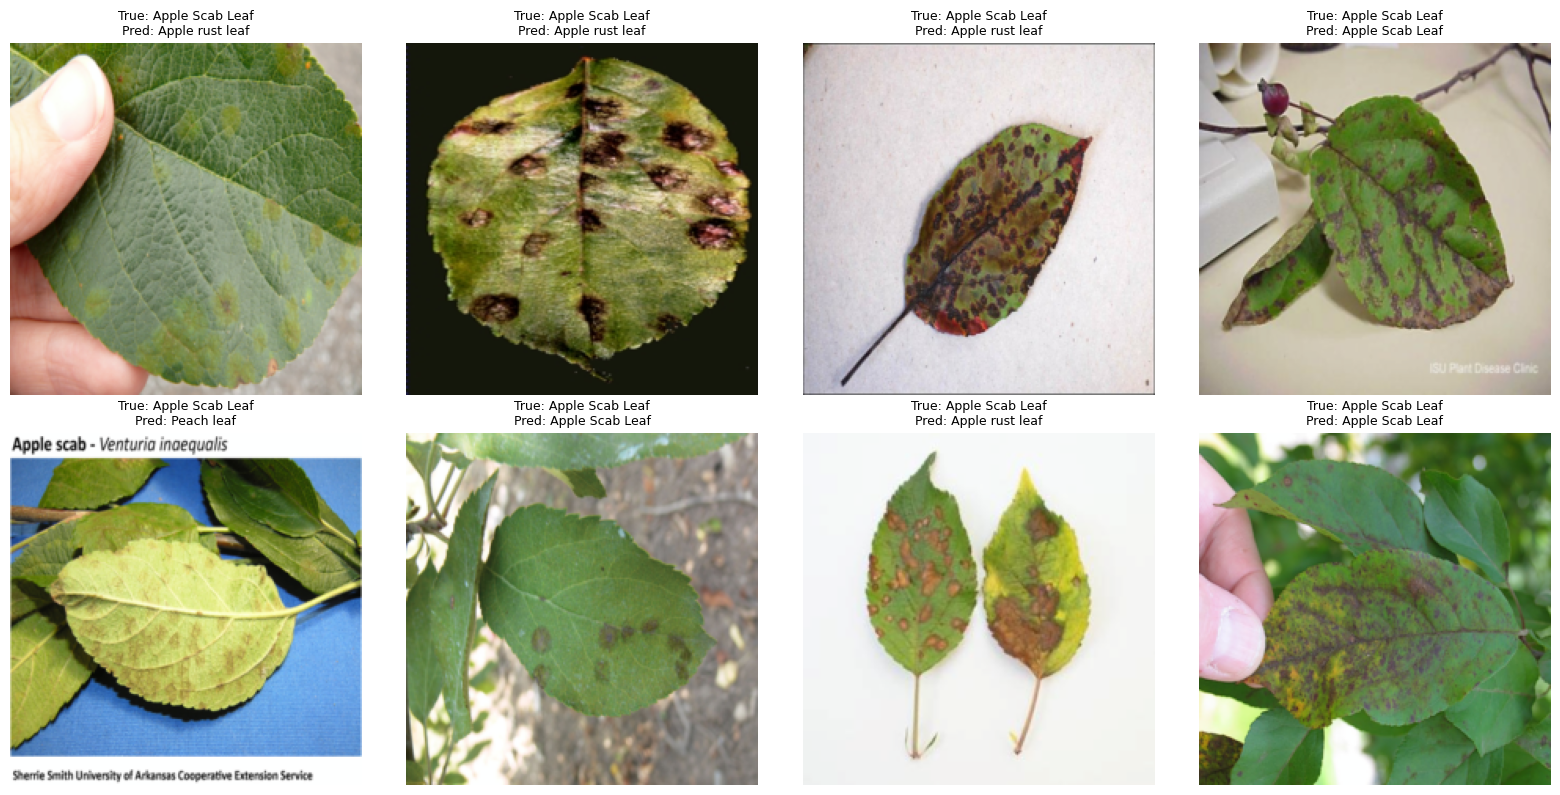


Proposed ResNet18 + CBAM predictions:


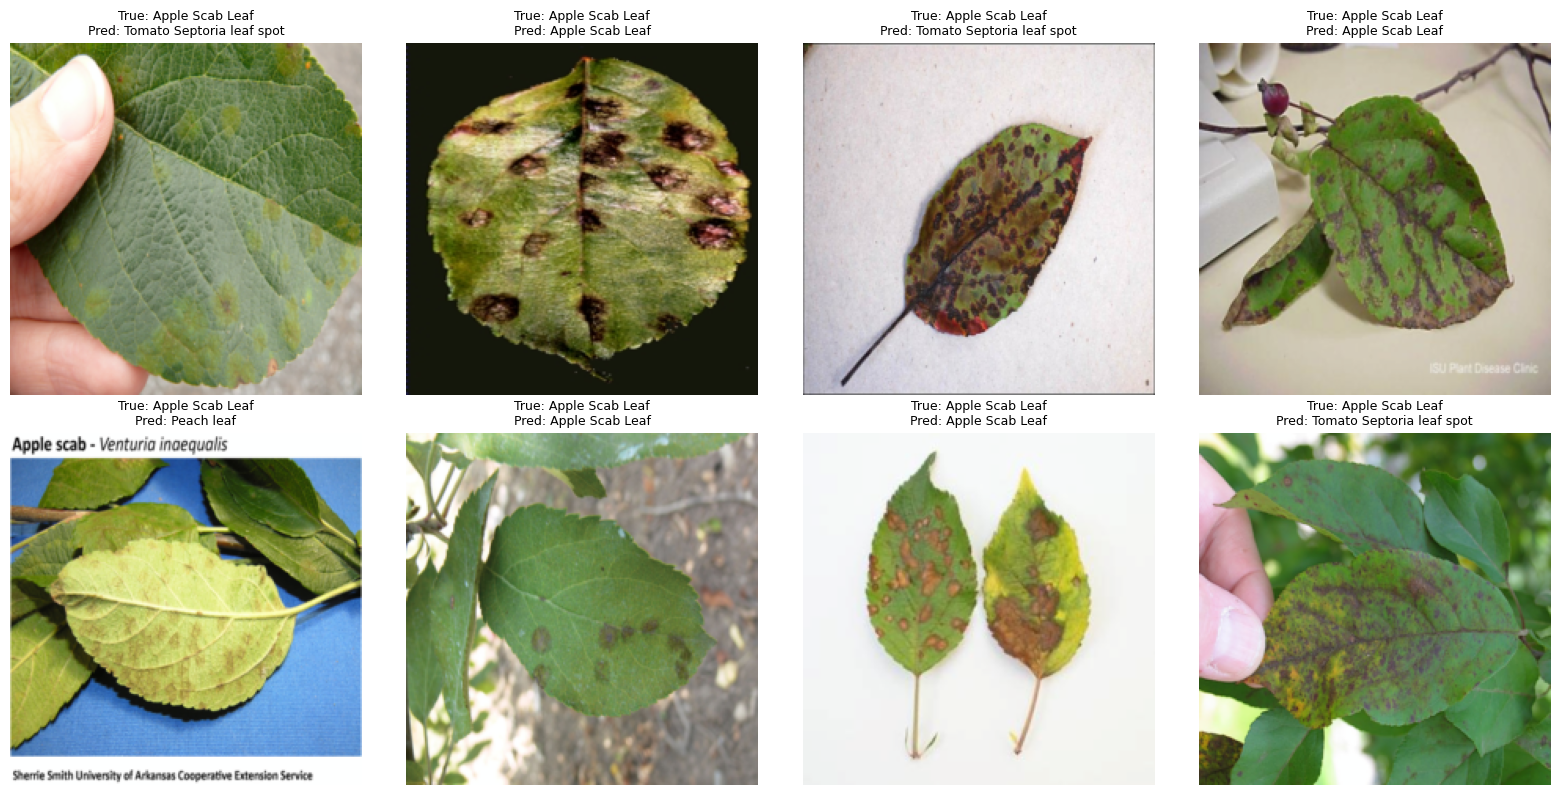

In [ ]:
# Step 6.3 - Generate predictions on unseen test data

import matplotlib.pyplot as plt

# Class names in correct index order
class_names = common_classes

def show_test_predictions(model, test_loader, class_names, device, num_images=8):

    model.eval()

    images_to_show = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            images_to_show.extend(images.cpu())
            true_labels.extend(labels.numpy())
            predicted_labels.extend(predictions.cpu().numpy())

            if len(images_to_show) >= num_images:
                break

    # Display first 8 test predictions
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i, ax in enumerate(axes.flat):

        image = images_to_show[i].permute(1, 2, 0).numpy()

        # Undo ImageNet normalization for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        image = image * std + mean
        image = np.clip(image, 0, 1)

        ax.imshow(image)

        true_name = class_names[true_labels[i]]
        predicted_name = class_names[predicted_labels[i]]

        ax.set_title(
            f"True: {true_name}\nPred: {predicted_name}",
            fontsize=9
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return true_labels, predicted_labels


print("Baseline ResNet18 predictions:")
baseline_test_labels, baseline_test_predictions = show_test_predictions(
    baseline_model,
    test_loader,
    class_names,
    device,
    num_images=8
)

print("\nProposed ResNet18 + CBAM predictions:")
proposed_test_labels, proposed_test_predictions = show_test_predictions(
    proposed_model,
    test_loader,
    class_names,
    device,
    num_images=8
)

<Figure size 1400x1200 with 0 Axes>

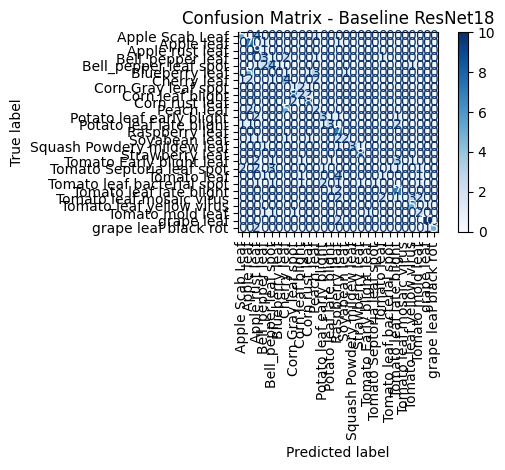

<Figure size 1400x1200 with 0 Axes>

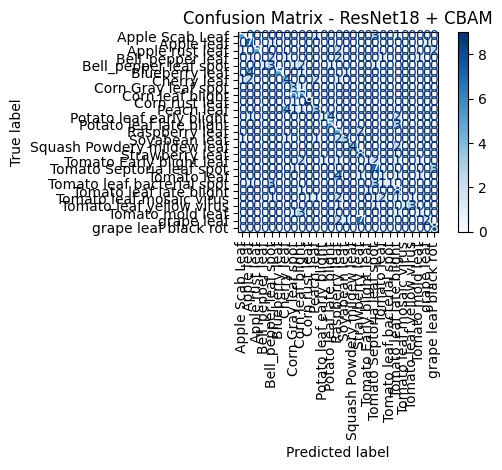

In [ ]:
# Step 6.4 - Generate confusion matrices

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrices
baseline_cm = confusion_matrix(
    baseline_labels,
    baseline_predictions
)

proposed_cm = confusion_matrix(
    proposed_labels,
    proposed_predictions
)

# Baseline ResNet18 confusion matrix
plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - Baseline ResNet18")
plt.tight_layout()
plt.show()


# Proposed ResNet18 + CBAM confusion matrix
plt.figure(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=proposed_cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("Confusion Matrix - ResNet18 + CBAM")
plt.tight_layout()
plt.show()

In [ ]:
# Step 6.5 - Compare baseline and proposed models

results = {
    "ResNet18": {
        "Accuracy": baseline_accuracy * 100,
        "Precision": baseline_precision * 100,
        "Recall": baseline_recall * 100,
        "F1-score": baseline_f1 * 100
    },
    "ResNet18 + CBAM": {
        "Accuracy": proposed_accuracy * 100,
        "Precision": proposed_precision * 100,
        "Recall": proposed_recall * 100,
        "F1-score": proposed_f1 * 100
    }
}

print("Model Performance Comparison")
print("-" * 50)

for model_name, metrics in results.items():
    print(f"\n{model_name}")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.2f}%")

print("\nParameter Comparison")
print("-" * 50)

baseline_params = sum(
    p.numel() for p in baseline_model.parameters()
)

proposed_params = sum(
    p.numel() for p in proposed_model.parameters()
)

parameter_increase = proposed_params - baseline_params
parameter_percentage = (
    parameter_increase / baseline_params
) * 100

print(f"ResNet18 parameters: {baseline_params:,}")
print(f"ResNet18 + CBAM parameters: {proposed_params:,}")
print(f"Additional parameters: {parameter_increase:,}")
print(f"Parameter increase: {parameter_percentage:.2f}%")

Model Performance Comparison
--------------------------------------------------

ResNet18
Accuracy: 42.80%
Precision: 38.08%
Recall: 42.80%
F1-score: 37.87%

ResNet18 + CBAM
Accuracy: 45.76%
Precision: 51.53%
Recall: 45.76%
F1-score: 42.68%

Parameter Comparison
--------------------------------------------------
ResNet18 parameters: 11,190,363
ResNet18 + CBAM parameters: 11,234,275
Additional parameters: 43,912
Parameter increase: 0.39%
